## Cosine Similarity Calculations
Cosine similarity is a measure of similarity between two non-zero vectors of an inner product space that measures the cosine of the angle between them. Similarity measures have a multiude of uses in machine learning projects; they come in handy when matching strings, measuring distance, and extracting features. This similarity measurement is particularly concerned with orientation, rather than magnitude. 
In this case study, you'll use the cosine similarity to compare both a numeric data within a plane and a text dataset for string matching.

Load the Python modules, including cosine_similarity, from sklearn.metrics.pairwise

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
plt.style.use('ggplot')
from scipy import spatial
from sklearn.metrics.pairwise import cosine_similarity

**<font color='teal'> Load the distance dataset into a dataframe. </font>**

In [2]:
df = pd.read_csv('data/distance_dataset.csv', index_col=0)
assert np.isfinite(df[['X', 'Y', 'Z']].to_numpy()).all()
print(f'Loaded {len(df):,} observations. ClusterID is excluded from the feature vectors.')
df.head()

Loaded 2,000 observations. ClusterID is excluded from the feature vectors.


,X,Y,Z,ClusterID
0,5.135779,4.167542,5.787635,4
1,4.280721,5.770909,6.091044,4
2,8.329098,7.540436,3.247239,2
3,5.470224,5.069249,5.768313,4
4,2.381797,2.402374,3.879101,1


### Cosine Similarity with clusters and numeric matrices

All points in our dataset can be thought of as feature vectors. We illustrate it here as we display the __Cosine Similarity__ between each feature vector in the YZ plane and the [5, 5] vector we chose as reference. The sklearn.metrics.pairwise module provides an efficient way to compute the __cosine_similarity__ for large arrays from which we can compute the similarity.

 **<font color='teal'> First, create a 2D and a 3D matrix from the dataframe. The 2D matrix should contain the 'Y' and 'Z' columns and the 3D matrix should contain the 'X','Y', and 'Z' columns.</font>**

In [3]:
matYZ = df[['Y', 'Z']].to_numpy(dtype=float)
mat = df[['X', 'Y', 'Z']].to_numpy(dtype=float)
assert (np.linalg.norm(matYZ, axis=1) > 0).all()
assert (np.linalg.norm(mat, axis=1) > 0).all()
print('2D shape:', matYZ.shape, '| 3D shape:', mat.shape)

2D shape: (2000, 2) | 3D shape: (2000, 3)


Calculate similarity to the reference **vectors** $(5,5)$ and $(5,5,5)$, then subtract from 1 to obtain **cosine distance**. These references are vectors from the origin, not planes.

For nonzero vectors, $s(u,v)=\frac{u\cdot v}{\|u\|\|v\|}$ and cosine distance is $1-s(u,v)$. Similarity ranges from −1 to 1; distance ranges from 0 to 2. Nonnegative vectors, as used here, have similarities between 0 and 1. Zero vectors have no mathematically defined cosine angle and are explicitly checked above.

In [4]:
cosineSimilarity3D = cosine_similarity(mat, [[5, 5, 5]])
cosineSimilarity2D = cosine_similarity(matYZ, [[5, 5]])
# Preserve the template's names, but these variables hold DISTANCE, not similarity.
simCosine3D = 1.0 - cosineSimilarity3D
simCosine = 1.0 - cosineSimilarity2D
# Verify the dot-product formula and SciPy's cosine-distance definition.
manual2D = (matYZ @ np.array([5., 5.])) / (np.linalg.norm(matYZ, axis=1) * np.linalg.norm([5., 5.]))
np.testing.assert_allclose(cosineSimilarity2D[:, 0], manual2D)
np.testing.assert_allclose(simCosine3D[:, 0], spatial.distance.cdist(mat, [[5, 5, 5]], metric='cosine')[:, 0], atol=1e-12)
assert np.all((cosineSimilarity2D >= -1e-12) & (cosineSimilarity2D <= 1 + 1e-12))
print(pd.DataFrame({'2D similarity': cosineSimilarity2D[:, 0],
                    '2D distance': simCosine[:, 0],
                    '3D similarity': cosineSimilarity3D[:, 0],
                    '3D distance': simCosine3D[:, 0]}).describe().round(4))

       2D similarity  2D distance  3D similarity  3D distance
count      2000.0000    2000.0000      2000.0000    2000.0000
mean          0.9592       0.0408         0.9594       0.0406
std           0.0358       0.0358         0.0365       0.0365
min           0.8208       0.0000         0.8203       0.0000
25%           0.9269       0.0076         0.9393       0.0106
50%           0.9691       0.0309         0.9690       0.0310
75%           0.9924       0.0731         0.9894       0.0607
max           1.0000       0.1792         1.0000       0.1797


The scatter plot colors points by **cosine distance** to the reference vector. Lower values mean closer alignment with the diagonal direction. Multiplying a nonzero vector by a positive scalar leaves its cosine similarity unchanged; the origin matters, and translating coordinates changes the result.

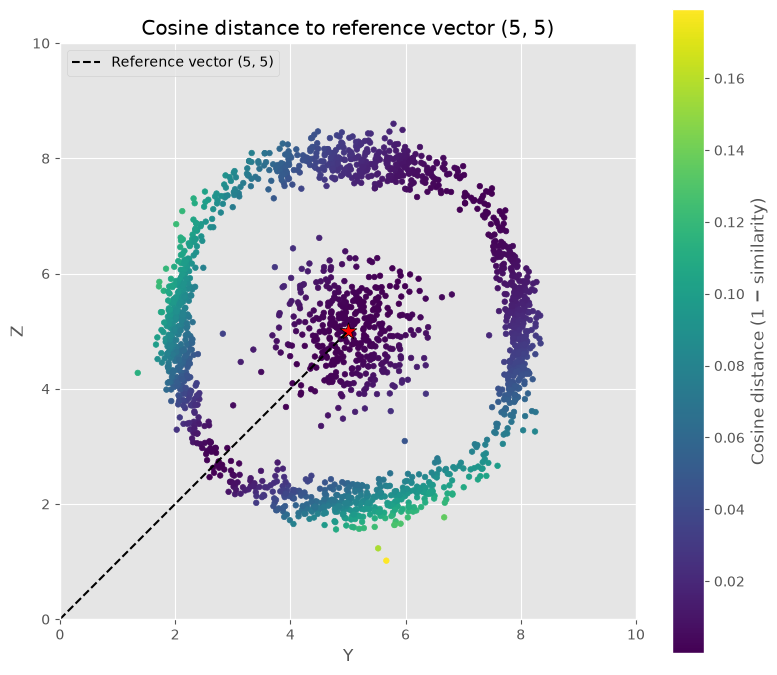

In [5]:
figCosine, ax = plt.subplots(figsize=(8, 7))
points = ax.scatter(df.Y, df.Z, c=simCosine[:, 0], s=16, cmap='viridis')
ax.plot([0, 5], [0, 5], '--', color='black', label='Reference vector (5, 5)')
ax.scatter([5], [5], marker='*', color='red', s=160, edgecolor='black')
ax.set(xlim=(0, 10), ylim=(0, 10), xlabel='Y', ylabel='Z',
       title='Cosine distance to reference vector (5, 5)')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left')
figCosine.colorbar(points, ax=ax, label='Cosine distance (1 − similarity)')
plt.tight_layout()
plt.show()

Plot the 3D coordinates, colored by cosine distance to reference vector $(5,5,5)$. The dashed line shows the vector from the origin.

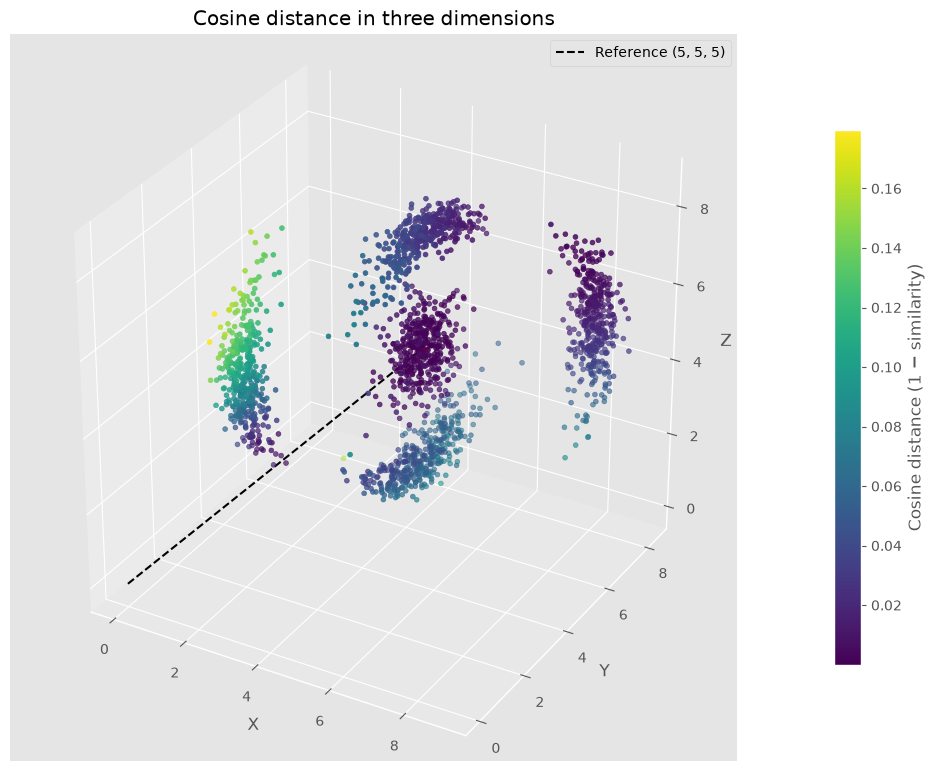

In [6]:
figCosine3D = plt.figure(figsize=(10, 8))
ax = figCosine3D.add_subplot(111, projection='3d')
p = ax.scatter(mat[:, 0], mat[:, 1], mat[:, 2], c=simCosine3D[:, 0], s=12, cmap='viridis')
ax.plot([0, 5], [0, 5], [0, 5], '--', color='black', label='Reference (5, 5, 5)')
ax.scatter([5], [5], [5], marker='*', color='red', s=150)
ax.set(xlabel='X', ylabel='Y', zlabel='Z', title='Cosine distance in three dimensions')
ax.set_box_aspect((1, 1, 1))
ax.legend()
figCosine3D.colorbar(p, ax=ax, shrink=0.7, pad=0.1, label='Cosine distance (1 − similarity)')
plt.tight_layout()
plt.show()

----

### Cosine Similarity with text data
This is a quick example of how you can use Cosine Similarity to compare different text values or names for record matching or other natural language proecessing needs. 
First, we use count vectorizer to create a vector for each unique word in our Document 0 and Document 1. 

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
Document1 = "Starbucks Coffee"
Document2 = "Essence of Coffee"

corpus = [Document1,Document2]

X_train_counts = count_vect.fit_transform(corpus)

pd.DataFrame(X_train_counts.toarray(),columns=count_vect.get_feature_names_out(),index=['Document 0','Document 1'])

,coffee,essence,of,starbucks
Document 0,1,0,0,1
Document 1,1,1,1,0


TF-IDF weights terms by their frequency in a document and their inverse document frequency in the fitted corpus. `TfidfVectorizer` also L2-normalizes rows by default. Common terms receive less weight than terms unique to a document; these weights depend on the corpus.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
trsfm=vectorizer.fit_transform(corpus)
pd.DataFrame(trsfm.toarray(),columns=vectorizer.get_feature_names_out(),index=['Document 0','Document 1'])

,coffee,essence,of,starbucks
Document 0,0.579739,0.000000,0.000000,0.814802
Document 1,0.449436,0.631667,0.631667,0.000000


Compare Document 0 with both documents. The self-similarity should be 1. The other score measures overlap in TF-IDF-weighted vocabulary; it is not the probability that these business names represent the same entity.

In [9]:
cosine_similarity(trsfm[0:1], trsfm)

array([[1.        , 0.26055567]])

Replace the current values for `Document 0` and `Document 1` with your own sentence or paragraph and apply the same steps as we did in the above example.

 **<font color='teal'> Combine the documents into a corpus.</font>**

In [10]:
Document1 = 'Machine learning models help predict customer demand for coffee.'
Document2 = 'Machine learning helps forecast coffee demand and reduce waste.'
corpus = [Document1, Document2]
for i, document in enumerate(corpus):
    print(f'Document {i}: {document}')

Document 0: Machine learning models help predict customer demand for coffee.
Document 1: Machine learning helps forecast coffee demand and reduce waste.


 **<font color='teal'> Apply the count vectorizer to the corpus to transform it into vectors.</font>**

In [11]:
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(corpus)
print('Count matrix shape:', X_train_counts.shape)

Count matrix shape: (2, 14)


 **<font color='teal'> Convert the vector counts to a dataframe with Pandas.</font>**

In [12]:
count_df = pd.DataFrame(X_train_counts.toarray(),
                        columns=count_vect.get_feature_names_out(),
                        index=['Document 0', 'Document 1'])
count_df

,and,coffee,customer,demand,for,forecast,help,helps,learning,machine,models,predict,reduce,waste
Document 0,0,1,1,1,1,0,1,0,1,1,1,1,0,0
Document 1,1,1,0,1,0,1,0,1,1,1,0,0,1,1


 **<font color='teal'> Apply TF-IDF to convert the vectors to unique frequency measures.</font>**

In [13]:
# Fit once on the combined corpus so both documents share one vocabulary and IDF weights.
vectorizer = TfidfVectorizer()
trsfm = vectorizer.fit_transform(corpus)
assert np.all(np.asarray(trsfm.getnnz(axis=1)) > 0)
tfidf_df = pd.DataFrame(trsfm.toarray(), columns=vectorizer.get_feature_names_out(),
                       index=['Document 0', 'Document 1'])
tfidf_df.round(4)

,and,coffee,customer,demand,for,forecast,help,helps,learning,machine,models,predict,reduce,waste
Document 0,0.0000,0.2684,0.3773,0.2684,0.3773,0.0000,0.3773,0.0000,0.2684,0.2684,0.3773,0.3773,0.0000,0.0000
Document 1,0.3773,0.2684,0.0000,0.2684,0.0000,0.3773,0.0000,0.3773,0.2684,0.2684,0.0000,0.0000,0.3773,0.3773


 **<font color='teal'> Use the cosine similarity function to get measures of similarity for the sentences or paragraphs in your original document.</font>**

In [14]:
similarity_matrix = cosine_similarity(trsfm)
np.testing.assert_allclose(similarity_matrix, similarity_matrix.T, atol=1e-12)
np.testing.assert_allclose(np.diag(similarity_matrix), np.ones(len(corpus)))
count_similarity = cosine_similarity(X_train_counts)[0, 1]
print(f'Count-vector cosine similarity: {count_similarity:.6f}')
print(f'TF-IDF cosine similarity: {similarity_matrix[0, 1]:.6f}')
print(f'TF-IDF cosine distance: {1 - similarity_matrix[0, 1]:.6f}')
shared_terms = count_df.columns[(count_df > 0).all(axis=0)].tolist()
print('Shared terms:', shared_terms)
pd.DataFrame(similarity_matrix, index=count_df.index, columns=count_df.index).round(4)

Count-vector cosine similarity: 0.444444
TF-IDF cosine similarity: 0.288254
TF-IDF cosine distance: 0.711746
Shared terms: ['coffee', 'demand', 'learning', 'machine']


,Document 0,Document 1
Document 0,1.0000,0.2883
Document 1,0.2883,1.0000


### Interpretation and practical applications

The numeric plots show direction relative to the origin, rather than physical proximity to the reference endpoint. For example, $(1,1)$ and $(10,10)$ both have similarity 1 to $(5,5)$. Feature scaling changes angles and should be chosen deliberately.

The original business-name example gives similarity **0.2606**. For the custom sentences, count-vector similarity is **0.4444**, TF-IDF similarity is **0.2883**, and TF-IDF distance is **0.7117**. TF-IDF downweights shared words relative to words occurring in only one sentence.

The two custom sentences share **coffee, demand, learning, machine**. Other related words remain separate: the default word vectorizer does not recognize *predict* and *forecast* as synonyms or equate *help* with *helps*. Neither stemming nor stop-word removal is enabled. Consequently, these scores describe weighted lexical overlap rather than complete semantic meaning.

For record matching, cosine similarity can rank candidate names, but a score alone cannot establish identity. Cleaning text, considering other attributes, and validating thresholds on labeled pairs are necessary. Character n-grams can help with spelling differences. For NLP, word TF-IDF supports lexical search and document comparison; semantic embeddings can capture relationships beyond exact word overlap.

Prepared with AI assistance. Review the formulas, outputs, and interpretation before submission.
